> [Amanda L Richer, Kent A Riemondy, Lakotah Hardie, Jay R Hesselberth, **Simultaneous measurement of biochemical phenotypes and gene expression in single cells**, *Nucleic Acids Research*, (2020)](https://doi.org/10.1093/nar/gkaa240)

> **Dataset:** Cell line models targeted with CRISPR technology and UNG<sup>KO</sup> and RNASEH2C<sup>KO</sup> used for single cell RNA experssion experiments (haicut-seq) in 3 timepoints. 
> - **Cell line:** Hap1 UNG<sup>KO</sup> (HZGHC001531c012) and RNASEH2C<sup>KO</sup> (HZGHC004633c003) cells.


**Aim:** 

# Batch effect 

https://github.com/JinmiaoChenLab/Batch-effect-removal-benchmarking

> Based on our results, Harmony, LIGER, and Seurat 3 are the recommended methods for batch integration. Due to its significantly shorter runtime, **Harmony** is recommended as the first method to try, with the other methods as viable alternatives.

In [1]:
import scanpy as sc
from utils import cluster

scanpy==1.7.1 anndata==0.7.5 umap==0.5.1 numpy==1.19.2 scipy==1.5.3 pandas==1.1.3 scikit-learn==0.24.1 statsmodels==0.12.2 python-igraph==0.8.3 leidenalg==0.8.3


In [2]:
mix = sc.read_h5ad('preprocessing/mix.h5ad.gz')

mix

AnnData object with n_obs × n_vars = 4865 × 18292
    obs: 'time', 'Uracil-45', 'riboG-44', 'riboG-repair', 'Uracil-repair'

In [3]:
mix_copy = mix

In [4]:
cluster(mix_copy)

mix_copy.obs.time = mix_copy.obs.time.astype('string')

... storing 'time' as categorical


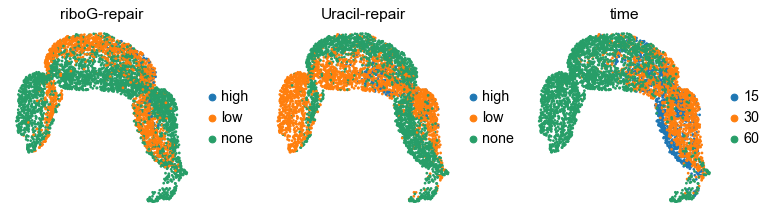

In [5]:
sc.pl.umap(mix_copy, color=['riboG-repair','Uracil-repair','time'])

In [9]:
sc.pp.combat(mix_copy, key='time',covariates=['riboG-repair','Uracil-repair'])#, inplace=False)

In [10]:
cluster(mix_copy)

/Users/abearab/anaconda3/envs/sc-analysis/lib/python3.6/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  foldchanges[global_indices]


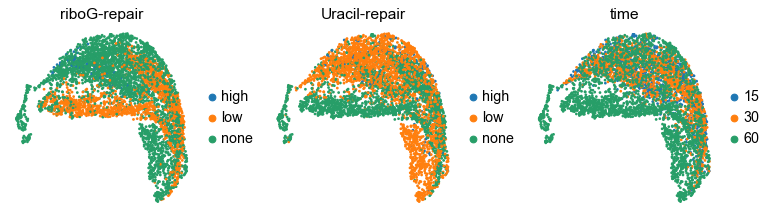

In [11]:
sc.pl.umap(mix_copy, color=['riboG-repair','Uracil-repair','time'])

Try [harmonypy](https://anaconda.org/bioconda/harmonypy)

These are the critical R packages I used to write [this note](https://slowkow.com/notes/harmony-animation/):
- [MUDAN](https://github.com/jefworks/MUDAN) by Jean Fan
- [Harmony](https://github.com/immunogenomics/harmony) and [presto](https://github.com/immunogenomics/presto) by Ilya Korsunsky
- [gganimate](https://gganimate.com/) by Thomas Lin Pedersen

Setup conda environment:

___
___
___

In [1]:
%load_ext rpy2.ipython

In [5]:
%%R 
require(devtools)
# devtools::install_github("JEFworks/MUDAN")


R[write to console]: Loading required package: devtools

R[write to console]: Error: package or namespace load failed for ‘devtools’ in loadNamespace(j <- i[[1L]], c(lib.loc, .libPaths()), versionCheck = vI[[j]]):
 namespace ‘processx’ 3.4.5 is being loaded, but >= 3.5.0 is required



In [132]:
%%R 
sessionInfo()

R version 4.0.3 (2020-10-10)
Platform: x86_64-apple-darwin13.4.0 (64-bit)
Running under: macOS Catalina 10.15.7

Matrix products: default
BLAS:   /System/Library/Frameworks/Accelerate.framework/Versions/A/Frameworks/vecLib.framework/Versions/A/libBLAS.dylib
LAPACK: /Users/abearab/anaconda3/envs/sc-analysis/lib/liblapack.3.9.0.dylib

locale:
[1] en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/en_US.UTF-8

attached base packages:
 [1] parallel  stats4    tools     stats     graphics  grDevices utils    
 [8] datasets  methods   base     

other attached packages:
 [1] patchwork_1.1.1             ggrepel_0.9.1              
 [3] BiocParallel_1.24.1         zinbwave_1.12.0            
 [5] scran_1.18.5                DESeq2_1.30.1              
 [7] forcats_0.5.1               stringr_1.4.0              
 [9] dplyr_1.0.5                 purrr_0.3.4                
[11] readr_1.4.0                 tidyr_1.1.3                
[13] tibble_3.1.1                ggplot2_3.3.3              
[15